In [1]:
import pandas as pd
import numpy as np
from scipy.stats import zscore, linregress
import matplotlib.pyplot as plt
import sys
import geopandas as gpd
import statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

sys.path.insert(1, '../ProcessEvents')
from config import CATCHMENT_LOOKUP_DICT, ENSEMBLE_MEMBERS, CATCHMENTS

def find_linear_relationship (df, variable1):
    x = df[variable1]
    y = df["10cm_area"]

    # Simple regression: flood area ~ rainfall intensity
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    r2_simple = r_value**2
    if p_value <0.005:
        p_value = '<0.05'
    else:
        p_value = round(p_value, 2)
    # print(" Simple:", f"{r2_simple:.2f}", p_value)  
    return [r2_simple, p_value]

In [2]:
fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails_v4/all_catchments.pkl"
rainfall_events_all_df = pd.read_pickle(fp)
rainfall_events_all_df = rainfall_events_all_df[rainfall_events_all_df['max_precip']<130].copy()
rainfall_events_all_df["length"] = (rainfall_events_all_df["stop_idx"] - rainfall_events_all_df["start_idx"]).astype("float32")

### Using the whole dataset

In [7]:
results = data.copy()
results['y_true'] = y.values
results['pred_lr'] = y_pred_lr
results['pred_rf'] = y_pred_rf

results['abs_err_lr'] = (results['y_true'] - results['pred_lr']).abs()
results['abs_err_rf'] = (results['y_true'] - results['pred_rf']).abs()

# Positive = RF does better at this point (smaller error)
results['rf_improvement'] = results['abs_err_lr'] - results['abs_err_rf']

results_sorted = results.sort_values('rf_improvement', ascending=False)
results_sorted

,max_precip,t_global,t_local,x_idx,y_idx,x_idx_global,y_idx_global,x_coord,y_coord,ens,...,peak_cell_water_prop,peak_cell_urban_prop,peak_cell_inside_prop,length,y_true,pred_lr,pred_rf,abs_err_lr,abs_err_rf,rf_improvement
1209,53.752640,4898,29,3,5,137,94,487500.0,437500.0,4,...,0.035076,0.020664,100.000000,52.0,3.2310,0.784465,2.966166,2.446535,0.264834,2.181701
1785,122.953636,2449,1,2,10,75,185,177500.0,892500.0,7,...,0.097167,0.000146,48.912800,17.0,0.5355,2.184148,0.691308,1.648648,0.155808,1.492840
3667,71.505081,5081,5,8,10,138,42,492500.0,177500.0,15,...,0.136032,0.252780,100.000000,12.0,3.4740,1.053452,2.531709,2.420548,0.942291,1.478257
1036,69.801048,5065,3,6,8,116,50,382500.0,217500.0,11,...,0.069665,0.523806,97.957603,12.0,3.5217,1.023448,2.446335,2.498252,1.075365,1.422887
3236,57.406303,5026,7,10,2,144,91,522500.0,422500.0,15,...,0.163597,0.015622,87.107208,23.0,6.8499,0.833011,2.120337,6.016889,4.729563,1.287326
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1650,46.666458,4890,29,1,2,79,167,197500.0,802500.0,15,...,0.294005,0.000305,82.489601,40.0,0.0468,0.742317,2.662830,0.695517,2.616030,-1.920513
2631,75.936363,4394,17,2,13,95,34,277500.0,137500.0,8,...,0.035597,0.004612,92.891205,34.0,0.4635,1.137049,3.072717,0.673549,2.609217,-1.935668
1880,48.357075,4336,6,11,5,93,76,267500.0,347500.0,9,...,0.056566,0.035203,72.403603,63.0,0.2799,0.682285,2.693475,0.402385,2.413575,-2.011190
4599,58.483814,4668,10,6,2,73,11,167500.0,22500.0,1,...,0.035562,0.052387,93.349609,67.0,0.6390,0.821356,2.987775,0.182356,2.348775,-2.166419


In [8]:
top_rf_wins = results_sorted.head(50)      # RF much better
top_lr_wins = results_sorted.tail(50)      # LR much better (or RF much worse)

top_rf_wins[variables + ['y_true', 'pred_lr', 'pred_rf']].describe()

,max_precip,month,mean_sm_2_before_event,fu_at_peak_new,fumax_at_peak,lu_at_peak,total_acc,peak_position_ratio,d50,gini,time_based_std,dry_ratio,max_quartile_index,random_variable,x_coord,y_coord,day_360,y_true,pred_lr,pred_rf
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,88.936805,7.580000,92.158139,0.001764,0.027252,0.066161,230.393549,0.515014,50.454808,0.894219,0.173761,8.563649,1.540000,-0.026529,122200.000000,762300.000000,201.140000,1.229634,1.082706,1.121618
std,24.344472,5.095376,20.693741,0.005569,0.002289,0.005945,121.072057,0.288426,25.587117,0.057455,0.084306,12.837045,1.164264,1.091046,23264.451291,45073.183122,157.683357,0.964168,0.273917,0.647806
min,34.083218,1.000000,0.000000,0.000000,0.026023,0.062959,69.627940,0.018868,1.707328,0.692336,0.005483,0.000000,0.000000,-2.241207,97500.000000,717500.000000,1.000000,0.031500,0.544949,0.100116
25%,71.678602,1.250000,92.156315,0.000000,0.026023,0.062959,137.116843,0.242566,26.442764,0.873850,0.123166,0.000000,0.000000,-0.726110,97500.000000,722500.000000,18.750000,0.453375,0.852071,0.600005
50%,89.356243,12.000000,98.674335,0.000040,0.026994,0.065532,231.881835,0.560569,53.340875,0.906413,0.164405,1.869322,2.000000,-0.046531,127500.000000,742500.000000,310.500000,0.772650,1.051633,0.955219
75%,107.136744,12.000000,100.792575,0.000358,0.027369,0.066431,280.560605,0.769231,72.294715,0.925598,0.254375,14.886364,2.750000,0.636010,132500.000000,801250.000000,347.000000,1.926225,1.286415,1.658063
max,128.090027,12.000000,107.653515,0.027369,0.037824,0.093629,523.305050,0.943182,93.946392,0.969718,0.319556,49.019608,3.000000,2.640238,167500.000000,862500.000000,360.000000,3.797100,1.643338,2.255301


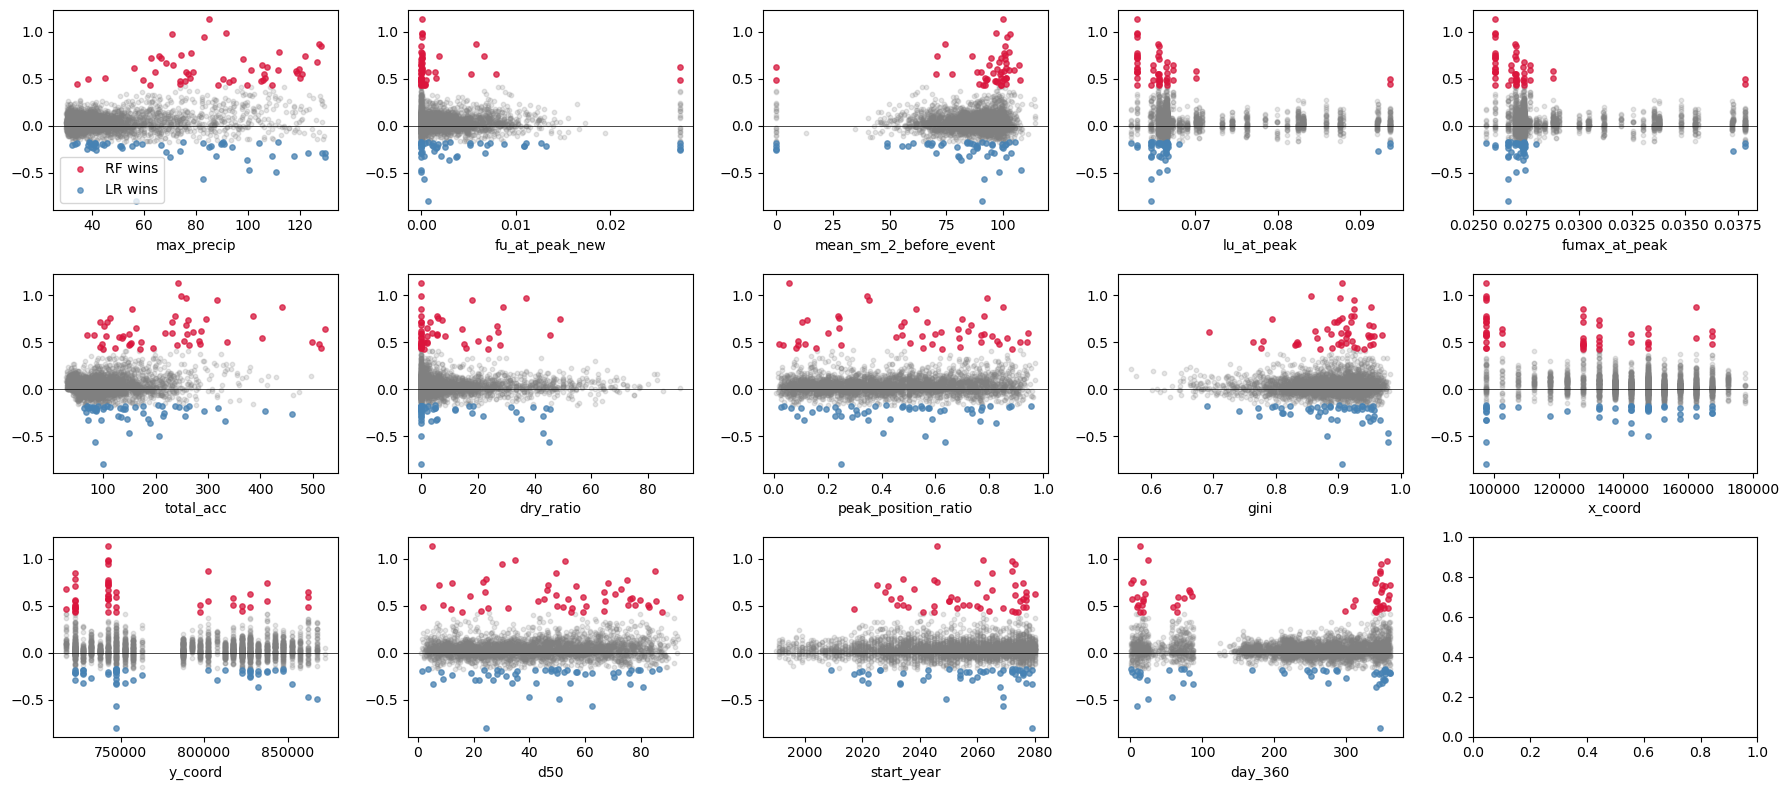

In [22]:
# import matplotlib.pyplot as plt

# fig, axes = plt.subplots(2, 4, figsize=(18, 8))
# key_vars = ['max_precip', 'fu_at_peak_new', 'mean_sm_2_before_event', 'lu_at_peak',
#             'total_acc', 'dry_ratio', 'peak_position_ratio', 'gini']

# for ax, var in zip(axes.flat, key_vars):
#     ax.scatter(results[var], results['rf_improvement'], alpha=0.2, s=10, color='grey')
#     ax.scatter(top_rf_wins[var], top_rf_wins['rf_improvement'], alpha=0.7, s=15, color='crimson')
#     ax.axhline(0, color='k', linewidth=0.5)
#     ax.set_xlabel(var)
#     ax.set_ylabel('RF improvement')

# plt.tight_layout()
# plt.show()

fig, axes = plt.subplots(3, 5, figsize=(18, 8))
key_vars = ['max_precip', 'fu_at_peak_new', 'mean_sm_2_before_event', 'lu_at_peak','fumax_at_peak',
            'total_acc', 'dry_ratio', 'peak_position_ratio', 'gini', 'x_coord', 'y_coord', 'd50',
           'start_year', 'day_360']

for ax, var in zip(axes.flat, key_vars):
    ax.scatter(results[var], results['rf_improvement'], alpha=0.2, s=10, color='grey')
    ax.scatter(top_rf_wins[var], top_rf_wins['rf_improvement'], alpha=0.7, s=15, color='crimson', label='RF wins')
    ax.scatter(top_lr_wins[var], top_lr_wins['rf_improvement'], alpha=0.7, s=15, color='steelblue', label='LR wins')
    ax.axhline(0, color='k', linewidth=0.5)
    ax.set_xlabel(var)

axes.flat[0].legend()
plt.tight_layout()
plt.show()

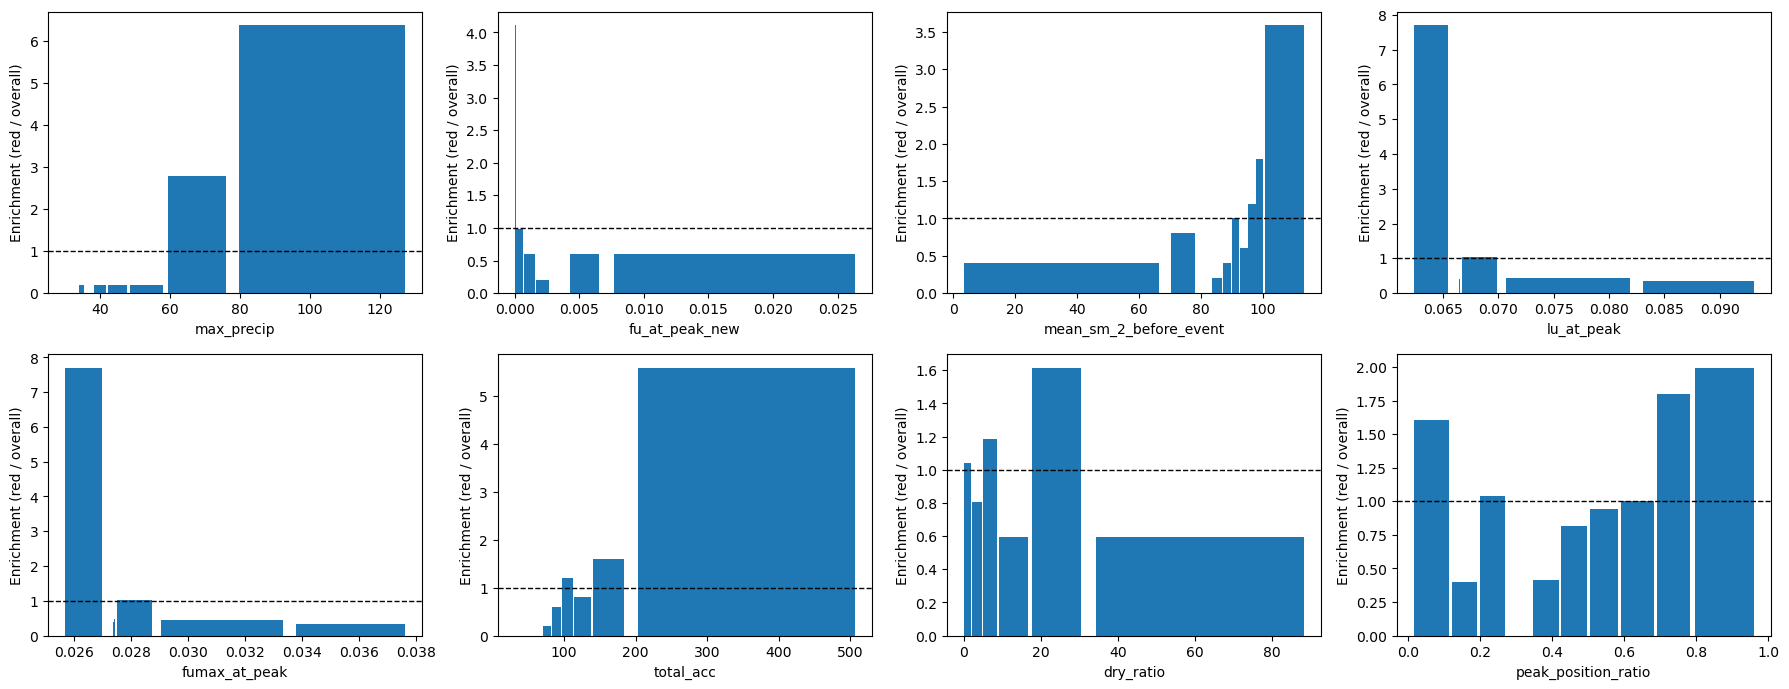

In [23]:
import numpy as np
import matplotlib.pyplot as plt

def enrichment_plot(var, data_full, data_red, n_bins=10, ax=None):
    bins = np.quantile(data_full[var].dropna(), np.linspace(0, 1, n_bins + 1))
    bins = np.unique(bins)  # in case of repeated values (e.g. fu_at_peak_new)
    
    full_counts, _ = np.histogram(data_full[var].dropna(), bins=bins)
    red_counts, _ = np.histogram(data_red[var].dropna(), bins=bins)
    
    full_frac = full_counts / full_counts.sum()
    red_frac = red_counts / red_counts.sum()
    
    enrichment = red_frac / full_frac  # >1 means over-represented among RF wins
    
    bin_centers = (bins[:-1] + bins[1:]) / 2
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3))
    ax.bar(bin_centers, enrichment, width=np.diff(bins)*0.9)
    ax.axhline(1, color='k', linewidth=1, linestyle='--')
    ax.set_xlabel(var)
    ax.set_ylabel('Enrichment (red / overall)')
    return ax

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, var in zip(axes.flat, key_vars):
    enrichment_plot(var, results, top_rf_wins, ax=ax)
plt.tight_layout()
plt.show()

In [119]:
import shap 
explainer = shap.TreeExplainer(rf)

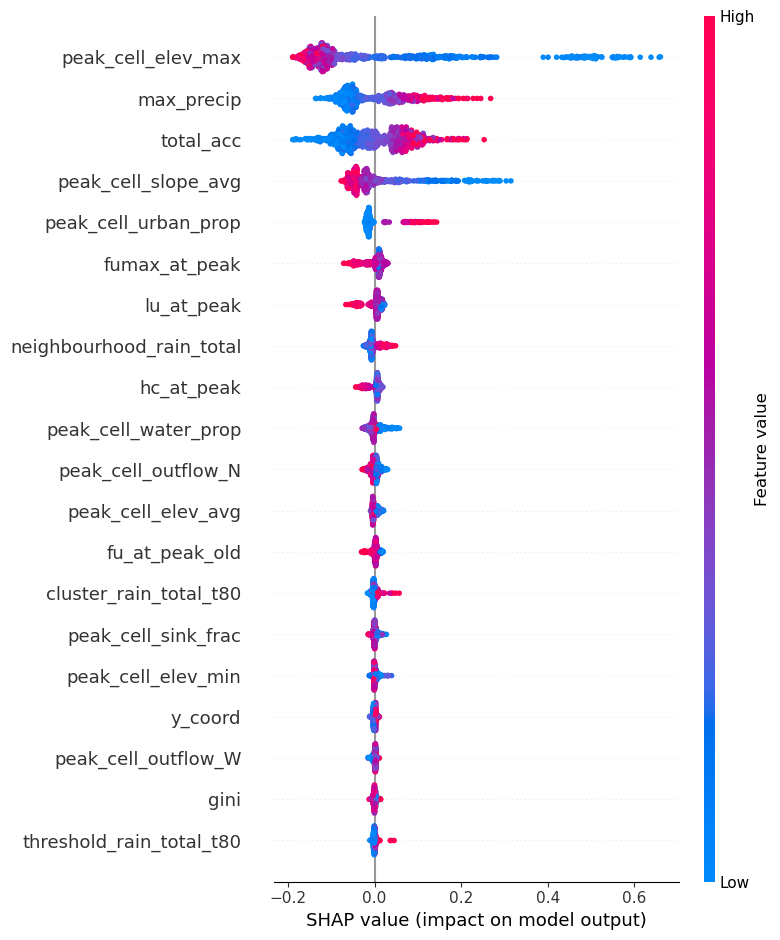

In [120]:
shap_values = explainer.shap_values(X)

# Global summary: which variables matter most overall, and in which direction
shap.summary_plot(shap_values, X, show=True)

In [123]:
periods = {
    'early (1980-2013)': (1980, 2013),
    'mid (2014-2046)':   (2014, 2046),
    'late (2047-2080)':  (2047, 2080),
}

period_interactions = {}

for label, (y0, y1) in periods.items():
    mask = (data['year'] >= y0) & (data['year'] <= y1)
    X_period = data.loc[mask, variables]
    y_period = data.loc[mask, '10cm_area']
    
    rf_period = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_period.fit(X_period, y_period)
    
    explainer_period = shap.TreeExplainer(rf_period)
    shap_int_period = explainer_period.shap_interaction_values(X_period)
    
    i = variables.index('fu_at_peak_new')
    j = variables.index('mean_sm_2_before_event')
    period_interactions[label] = shap_int_period[:, i, j] * 2

for label, vals in period_interactions.items():
    print(f"{label}: mean |interaction| = {np.abs(vals).mean():.4f}, "
          f"mean interaction = {vals.mean():.4f}")

KeyboardInterrupt: 

In [62]:
subset[['fumax_at_peak', 'fu_at_peak_old', 'lu_at_peak']].std()
subset[['fumax_at_peak', 'fu_at_peak_old', 'lu_at_peak']].describe()

,fumax_at_peak,fu_at_peak_old,lu_at_peak
count,3226.000000,3226.000000,3226.000000
mean,0.028517,0.022475,0.069430
std,0.002781,0.002364,0.007228
min,0.025601,0.019591,0.062196
25%,0.027330,0.020994,0.066337
50%,0.027395,0.021601,0.066494
75%,0.027545,0.022723,0.067001
max,0.037824,0.032590,0.093629


In [73]:
from sklearn.model_selection import cross_val_score

def loco_test(X_full, y, drop_var, cv):
    X_reduced = X_full.drop(columns=[drop_var])
    rf_test = RandomForestRegressor(n_estimators=100, random_state=42)
    r2 = cross_val_score(rf_test, X_reduced, y, cv=cv, scoring='r2').mean()
    return r2

baseline_r2 = cross_val_score(rf, X, y, cv=cv, scoring='r2').mean()
print(f"Full model R²: {baseline_r2:.4f}\n")

for var in ['fumax_at_peak', 'fu_at_peak_old', 'lu_at_peak']:
    r2_dropped = loco_test(X, y, var, cv)
    print(f"Drop {var:20s} → R² = {r2_dropped:.4f}  (Δ = {baseline_r2 - r2_dropped:+.4f})")

Full model R²: 0.8143

Drop fumax_at_peak        → R² = 0.8143  (Δ = +0.0000)
Drop fu_at_peak_old       → R² = 0.8133  (Δ = +0.0010)
Drop lu_at_peak           → R² = 0.8131  (Δ = +0.0012)


Mean |interaction|: 0.0007


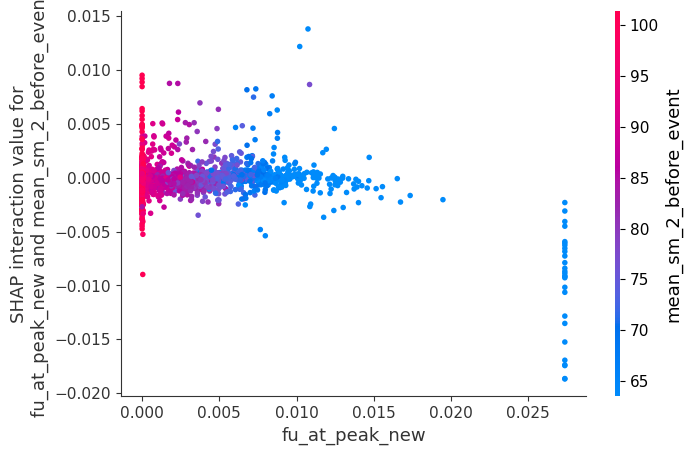

In [28]:
shap_interaction_values = explainer.shap_interaction_values(X)
i = variables.index('fu_at_peak_new')
j = variables.index('mean_sm_2_before_event')

interaction_hc_moisture = shap_interaction_values[:, i, j] * 2  
# *2 because SHAP splits each pairwise interaction symmetrically across [i,j] and [j,i]

print(f"Mean |interaction|: {np.abs(interaction_hc_moisture).mean():.4f}")

shap.dependence_plot(
    (i, j), shap_interaction_values, X,
    display_features=X)

In [29]:
n_vars = len(variables)
interaction_strength = np.zeros((n_vars, n_vars))

for a in range(n_vars):
    for b in range(n_vars):
        if a != b:
            interaction_strength[a, b] = np.abs(shap_interaction_values[:, a, b]).mean()

interaction_df = pd.DataFrame(interaction_strength, index=variables, columns=variables)

# Top interactions, excluding self-interactions (diagonal)
interaction_pairs = (
    interaction_df.where(np.triu(np.ones(interaction_df.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)
print(interaction_pairs.head(15))

max_precip     total_acc                 0.019500
               x_coord                   0.013785
               lu_at_peak                0.006429
               y_coord                   0.006060
               fumax_at_peak             0.005636
               peak_position_ratio       0.005184
total_acc      peak_position_ratio       0.005140
               x_coord                   0.004848
max_precip     d50                       0.004756
lu_at_peak     total_acc                 0.004463
max_precip     mean_sm_2_before_event    0.003903
lu_at_peak     x_coord                   0.002845
fumax_at_peak  total_acc                 0.002823
max_precip     time_based_std            0.002567
total_acc      d50                       0.002557
dtype: float64


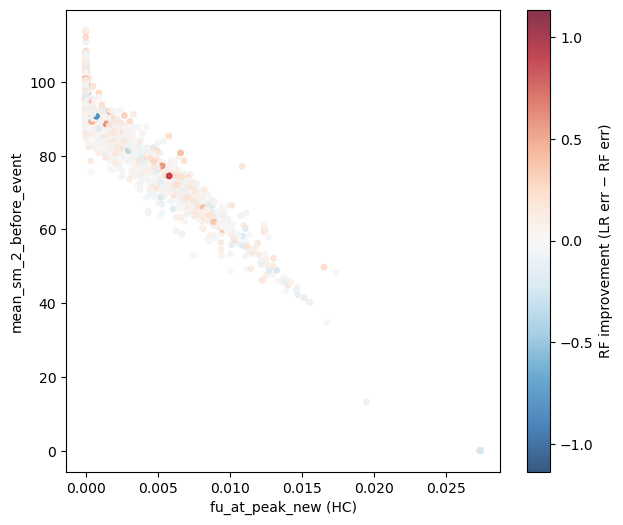

In [11]:
plt.figure(figsize=(7,6))
sc = plt.scatter(results['fu_at_peak_new'], results['mean_sm_2_before_event'],
                  c=results['rf_improvement'], cmap='RdBu_r', vmin=-results['rf_improvement'].abs().max(),
                  vmax=results['rf_improvement'].abs().max(), s=15, alpha=0.8)
plt.colorbar(sc, label='RF improvement (LR err − RF err)')
plt.xlabel('fu_at_peak_new (HC)')
plt.ylabel('mean_sm_2_before_event')
plt.show()

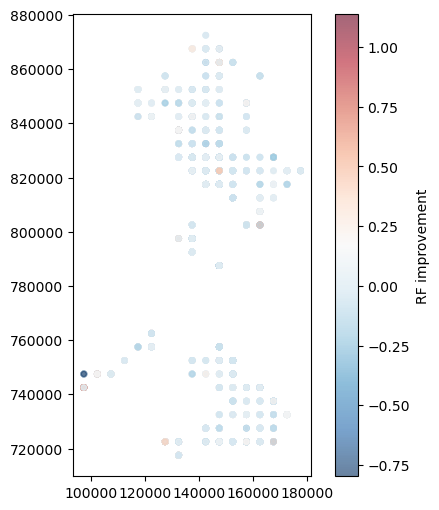

In [12]:
plt.figure(figsize=(6,6))
plt.scatter(results['x_coord'], results['y_coord'], c=results['rf_improvement'],
            cmap='RdBu_r', s=15, alpha=0.6)
plt.colorbar(label='RF improvement')
plt.gca().set_aspect('equal')
plt.show()

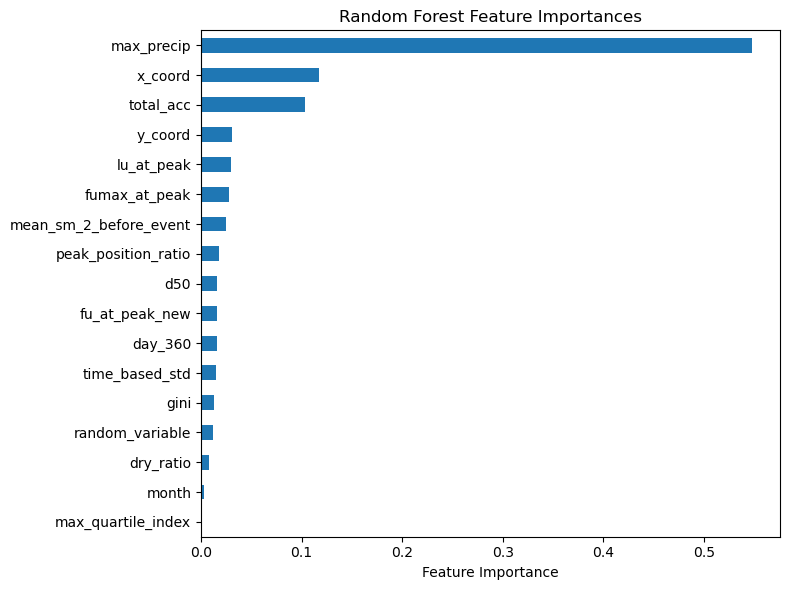

In [9]:
from sklearn.ensemble import RandomForestRegressor

importances = pd.Series(rf.feature_importances_,index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.sort_values().plot(kind="barh")
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances")
plt.tight_layout()

In [31]:
from sklearn.inspection import permutation_importance

rf.fit(X, y)

perm = permutation_importance(rf, X, y,n_repeats=20,random_state=42,scoring='r2')

importance_rf = pd.DataFrame({'variable': X.columns,'importance': perm.importances_mean,'std': perm.importances_std
}).sort_values('importance', ascending=False)

print(importance_rf)

                  variable  importance       std
4            fumax_at_peak    0.493409  0.021007
5               lu_at_peak    0.338075  0.013852
0               max_precip    0.201461  0.010662
6                total_acc    0.194711  0.020446
2   mean_sm_2_before_event    0.040155  0.004651
9                     gini    0.017527  0.000946
3           fu_at_peak_new    0.016942  0.000585
10          time_based_std    0.012757  0.000543
8                      d50    0.011426  0.000734
7      peak_position_ratio    0.011381  0.000585
1                    month    0.011202  0.001005
11               dry_ratio    0.008259  0.000498
12      max_quartile_index    0.000673  0.000096


In [22]:
from sklearn.preprocessing import StandardScaler

X_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X),
    columns=X.columns,
    index=X.index
)

lr_scaled = LinearRegression()
lr_scaled.fit(X_scaled, y)

importance_lr = pd.Series(
    lr_scaled.coef_,
    index=X.columns
).sort_values(key=abs, ascending=False)

print(importance_lr)

(np.float64(0.7598668489043616), np.float64(0.10471595232819793))

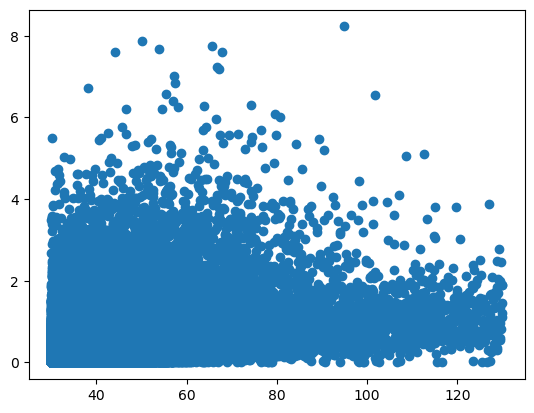

In [4]:
r2_simple, p_value = find_linear_relationship(rainfall_events_all_df, "max_precip")
plt.scatter(rainfall_events_all_df['max_precip'], rainfall_events_all_df['10cm_area'])
plt.show()